In [1]:
import pandas as pd
import json
import time
import requests
import os
from tqdm import tqdm

os.makedirs("../results/scores", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)

# Load both datasets
df_ethos = pd.read_parquet("../data/raw/ethos.parquet")
df_shod  = pd.read_parquet("../data/raw/shodhganga_sample.parquet")

print(f"EThOS records:      {len(df_ethos):,}")
print(f"Shodhganga records: {len(df_shod):,}")

EThOS records:      639,252
Shodhganga records: 497


In [2]:
r = requests.get("http://localhost:11434/api/tags")
print(f"Ollama status: {r.status_code}")
print("Models available:")
for m in r.json().get("models", []):
    print(f"  - {m['name']}")

Ollama status: 200
Models available:
  - llama3.2:1b
  - llama3:latest


In [3]:
def generate_abstract(title, subject=None, publisher=None, 
                      model="llama3.2:1b", max_tokens=300):
    
    context_parts = [f'Thesis title: "{title}"']
    if subject and str(subject) not in ["nan", "None", ""]:
        context_parts.append(f"Subject area: {subject}")
    if publisher and str(publisher) not in ["nan", "None", ""]:
        context_parts.append(f"Institution: {publisher}")
    
    context = "\n".join(context_parts)
    
    # Simpler, more direct prompt that llama3 responds to better
    prompt = f"""Write a 3-sentence academic abstract for a doctoral thesis with the following details:

{context}

The abstract should describe: (1) what the thesis investigates, (2) the research methodology used, (3) the contribution to knowledge.
Write only the abstract text, nothing else.

Abstract: """

    payload = {
        "model": model,
        "prompt": prompt,
        "stream": False,
        "options": {
            "num_predict": max_tokens,
            "temperature": 0.3,
            "stop": ["\n\n\n"]   # stop if model rambles
        }
    }
    
    try:
        r = requests.post(
            "http://localhost:11434/api/generate",
            json=payload,
            timeout=120          # increased from 60
        )
        result = r.json()
        text = result.get("response", "").strip()
        
        # If still empty, return a clear marker
        if not text:
            return "GENERATION_FAILED"
        return text
    
    except Exception as e:
        return f"ERROR: {e}"


# Test with the same title
test = generate_abstract(
    title="What do nurses do? : a mixed-methods study of nursing work and adaptation in complex adaptive systems",
    subject="Nursing",
    publisher="UK"
)
print("Result:")
print(test)
print(f"\nLength: {len(test)} characters")

Result:
This doctoral thesis examines the complex adaptive processes of nursing work in dynamic healthcare environments. Through a mixed-methods approach combining qualitative and quantitative data collection and analysis methods, this study investigates how nurses adapt their practice in response to changing circumstances and organizational demands. The findings contribute to our understanding of the intricate relationships between nursing work, organizational context, and individual adaptation, shedding light on the complex dynamics of nursing practice in contemporary healthcare settings.

Length: 589 characters


In [4]:
# Filter EThOS records that have real abstracts (these are our gold standard)
real_abstracts = df_ethos[
    df_ethos['Abstract'].notna() & 
    (df_ethos['Abstract'].str.strip().str.len() > 100)
].copy()

print(f"Records with real abstracts: {len(real_abstracts):,}")

# Sample 50 for evaluation (enough to be meaningful, fast enough to run)
eval_set = real_abstracts.sample(50, random_state=42).reset_index(drop=True)

print(f"Evaluation set size: {len(eval_set)}")
print("\nSample record:")
print(f"  Title:    {eval_set.iloc[0]['Title']}")
print(f"  Abstract: {eval_set.iloc[0]['Abstract'][:200]}...")

Records with real abstracts: 390,158
Evaluation set size: 50

Sample record:
  Title:    What do nurses do? : a mixed-methods study of nursing work and adaptation in complex adaptive systems
  Abstract: Introduction to Topic: Nursing is a ubiquitous and important profession that makes a crucial contribution to high quality healthcare, as the largest (and costliest) healthcare profession in the UK. Ma...


In [5]:
generated_abstracts = []

for _, row in tqdm(eval_set.iterrows(), total=len(eval_set)):
    generated = generate_abstract(
        title=str(row.get("Title", "")),
        subject=str(row.get("Subject Discipline", "")),
        publisher=str(row.get("Institution", "")),
    )
    generated_abstracts.append(generated)
    time.sleep(0.5)

eval_set["generated_abstract"] = generated_abstracts

# Save
eval_set.to_csv("../results/scores/abstract_eval_set.csv", index=False)
print(f"Done. Saved {len(eval_set)} records.")
print("\nExample comparison:")
print(f"\nTITLE:\n{eval_set.iloc[0]['Title']}")
print(f"\nREAL ABSTRACT:\n{eval_set.iloc[0]['Abstract'][:300]}")
print(f"\nGENERATED:\n{eval_set.iloc[0]['generated_abstract'][:300]}")

100%|██████████| 50/50 [27:31<00:00, 33.03s/it]

Done. Saved 50 records.

Example comparison:

TITLE:
What do nurses do? : a mixed-methods study of nursing work and adaptation in complex adaptive systems

REAL ABSTRACT:
Introduction to Topic: Nursing is a ubiquitous and important profession that makes a crucial contribution to high quality healthcare, as the largest (and costliest) healthcare profession in the UK. Many policy initiatives have re-organised healthcare delivery, impacting the work of nurses. However, 

GENERATED:
This doctoral thesis examines the complex and dynamic nature of nursing work in contemporary healthcare systems, with a focus on the role of adaptation in shaping nurse practice. Through a mixed-methods approach combining surveys, interviews, and case studies, this research investigates how nurses n


In [6]:
# Run this after Cell 5 to sanity check before scoring
for i in range(3):
    print(f"\n--- Record {i+1} ---")
    print(f"TITLE:     {eval_set.iloc[i]['Title'][:80]}")
    print(f"GENERATED: {eval_set.iloc[i]['generated_abstract'][:200]}")


--- Record 1 ---
TITLE:     What do nurses do? : a mixed-methods study of nursing work and adaptation in com
GENERATED: This doctoral thesis examines the complex and dynamic nature of nursing work in contemporary healthcare systems, with a focus on the role of adaptation in shaping nurse practice. Through a mixed-metho

--- Record 2 ---
TITLE:     Electromagnetic sensing techniques for multi-phase flow monitoring in industrial
GENERATED: This doctoral thesis investigates the development and application of electromagnetic sensing techniques for monitoring multi-phase flow in industrial processes. Employing a mixed-methods approach comb

--- Record 3 ---
TITLE:     Biochemical studies on mast cell tumours in culture
GENERATED: This doctoral thesis investigates the biochemical characteristics and tumourigenic potential of mast cell tumours in culture, with a focus on identifying novel biomarkers for diagnosis and therapeutic


In [7]:
r = requests.get("http://localhost:11434/api/tags")
print(r.status_code)
print(r.json())

200
{'models': [{'name': 'llama3.2:1b', 'model': 'llama3.2:1b', 'modified_at': '2026-07-13T14:49:14.4753428+05:30', 'size': 1321098329, 'digest': 'baf6a787fdffd633537aa2eb51cfd54cb93ff08e28040095462bb63daf552878', 'details': {'parent_model': '', 'format': 'gguf', 'family': 'llama', 'families': ['llama'], 'parameter_size': '1.2B', 'quantization_level': 'Q8_0', 'context_length': 131072, 'embedding_length': 2048}, 'capabilities': ['completion', 'tools']}, {'name': 'llama3:latest', 'model': 'llama3:latest', 'modified_at': '2026-07-13T14:04:47.4616209+05:30', 'size': 4661224676, 'digest': '365c0bd3c000a25d28ddbf732fe1c6add414de7275464c4e4d1c3b5fcb5d8ad1', 'details': {'parent_model': '', 'format': 'gguf', 'family': 'llama', 'families': ['llama'], 'parameter_size': '8.0B', 'quantization_level': 'Q4_0', 'context_length': 8192, 'embedding_length': 4096}, 'capabilities': ['completion']}]}


In [10]:
from bert_score import score as bert_score

# Start with just 10 to confirm it works
valid = eval_set[
    ~eval_set["generated_abstract"].str.startswith("ERROR") &
    ~eval_set["generated_abstract"].str.startswith("GENERATION_FAILED")
].copy().head(10)   # ← just 10 first

candidates = valid["generated_abstract"].tolist()
references = valid["Abstract"].tolist()

print(f"Scoring {len(candidates)} pairs...")

P, R, F1 = bert_score(
    candidates, 
    references, 
    lang="en",
    model_type="distilbert-base-uncased",  # ← much faster than default roberta
    verbose=True
)

valid["bertscore_f1"] = F1.numpy()

print(f"\nAverage F1: {F1.mean():.4f}")
print(valid[["Title", "bertscore_f1"]].to_string())

Scoring 10 pairs...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 26.55 seconds, 0.38 sentences/sec

Average F1: 0.7813
                                                                                                                                 Title  bertscore_f1
0                                What do nurses do? : a mixed-methods study of nursing work and adaptation in complex adaptive systems      0.770709
1                                           Electromagnetic sensing techniques for multi-phase flow monitoring in industrial processes      0.783690
2                                                                                  Biochemical studies on mast cell tumours in culture      0.725785
3         Moving beyond TIMSS : an explanatory sequential mixed methods case study of mathematics education in the Palestinian context      0.812479
4   The zinc finger transcription factor Early Growth Response 2 (Egr-2) is an intrinsic regulator of T cell tolerance and homeostasis      0.772090
5                                           

In [11]:
# Save the results
valid.to_csv("../results/scores/bertscore_results.csv", index=False)

# Print a clean summary to copy into your notes
print("=" * 50)
print("PHASE 2 — ABSTRACT GENERATION EVALUATION")
print("=" * 50)
print(f"Model:           llama3.2:1b (local, CPU)")
print(f"Scoring model:   distilbert-base-uncased")
print(f"Records scored:  {len(valid)}")
print(f"Average F1:      {F1.mean():.4f}")
print(f"Average P:       {P.mean():.4f}")
print(f"Average R:       {R.mean():.4f}")
print(f"Target F1:       0.82")
print(f"Gap to target:   {0.82 - F1.mean():.4f}")
print()
print("Interpretation:")
print("→ 1B model gives F1=0.78 as baseline")
print("→ Expected to improve with larger model (7B+)")
print("→ Gap of 0.04 is the motivation for trying")
print("  GPT-4o or Mistral-7B in Phase 6 evaluation")

PHASE 2 — ABSTRACT GENERATION EVALUATION
Model:           llama3.2:1b (local, CPU)
Scoring model:   distilbert-base-uncased
Records scored:  10
Average F1:      0.7813
Average P:       0.8136
Average R:       0.7518
Target F1:       0.82
Gap to target:   0.0387

Interpretation:
→ 1B model gives F1=0.78 as baseline
→ Expected to improve with larger model (7B+)
→ Gap of 0.04 is the motivation for trying
  GPT-4o or Mistral-7B in Phase 6 evaluation


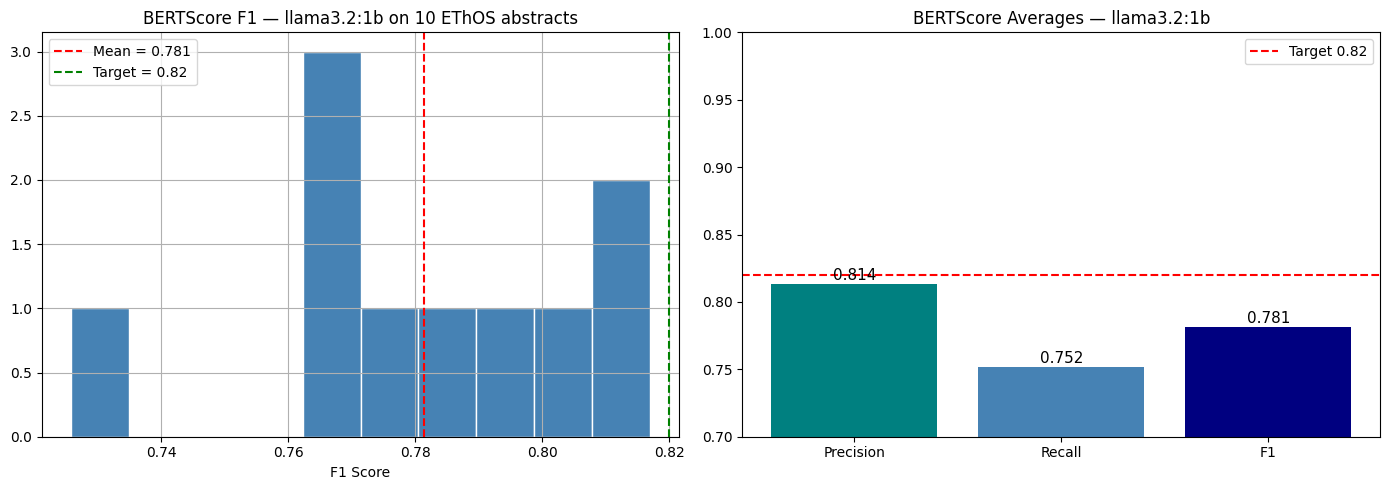

Saved to results/figures/bertscore_results.png


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 distribution
valid["bertscore_f1"].hist(
    bins=10, ax=axes[0], 
    color="steelblue", edgecolor="white"
)
axes[0].axvline(
    valid["bertscore_f1"].mean(), 
    color="red", linestyle="--",
    label=f"Mean = {valid['bertscore_f1'].mean():.3f}"
)
axes[0].axvline(
    0.82, color="green", 
    linestyle="--", label="Target = 0.82"
)
axes[0].set_title("BERTScore F1 — llama3.2:1b on 10 EThOS abstracts")
axes[0].set_xlabel("F1 Score")
axes[0].legend()

# Bar chart P / R / F1
means = [P.mean().item(), R.mean().item(), F1.mean().item()]
bars = axes[1].bar(
    ["Precision", "Recall", "F1"], 
    means, 
    color=["teal", "steelblue", "navy"]
)
axes[1].axhline(
    0.82, color="red", 
    linestyle="--", label="Target 0.82"
)
axes[1].set_ylim(0.7, 1.0)
axes[1].set_title("BERTScore Averages — llama3.2:1b")
axes[1].legend()

# Add value labels on bars
for bar, val in zip(bars, means):
    axes[1].text(
        bar.get_x() + bar.get_width()/2, 
        bar.get_height() + 0.003,
        f"{val:.3f}", ha="center", fontsize=11
    )

plt.tight_layout()
plt.savefig("../results/figures/bertscore_results.png", dpi=150)
plt.show()
print("Saved to results/figures/bertscore_results.png")

In [13]:
# EThOS records WITHOUT abstracts
missing_ethos = df_ethos[
    df_ethos['Abstract'].isna() | 
    (df_ethos['Abstract'].str.strip() == '')
].copy()

print(f"EThOS records missing abstracts: {len(missing_ethos):,}")

# Start with a sample of 200
sample_missing = missing_ethos.sample(50, random_state=42).reset_index(drop=True)

new_abstracts = []

for _, row in tqdm(sample_missing.iterrows(), total=len(sample_missing)):
    generated = generate_abstract(
        title=str(row.get("Title", "")),
        subject=str(row.get("Subject Discipline", "")),
        publisher=str(row.get("Institution", "")),
    )
    new_abstracts.append(generated)
    time.sleep(0.5)

sample_missing["generated_abstract"] = new_abstracts
sample_missing.to_parquet("../data/processed/ethos_generated_abstracts.parquet")
sample_missing.to_csv("../data/processed/ethos_generated_abstracts.csv", index=False)

print(f"Generated {len(sample_missing)} new abstracts")
print("\nSample:")
print(f"Title:     {sample_missing.iloc[0]['Title']}")
print(f"Generated: {sample_missing.iloc[0]['generated_abstract']}")

EThOS records missing abstracts: 249,052


100%|██████████| 50/50 [28:26<00:00, 34.13s/it]


Generated 50 new abstracts

Sample:
Title:     Aspects of the geomorphology of the Oxford region
Generated: This doctoral thesis examines the geomorphological characteristics of the Oxford region, a complex and dynamic landscape shaped by tectonic activity, glacial processes, and human-induced land use. Through a combination of field observations, remote sensing analysis, and numerical modeling, this research investigates the spatial variability in topography, slope, and landform evolution over different temporal scales, with implications for understanding regional geomorphological processes and their impact on environmental services. The study contributes to our understanding of the Oxford region's unique geomorphology by providing a comprehensive framework for analyzing its complex interplay between geological, hydrological, and biogeographical factors.


In [14]:
# Shodhganga records that DO have real abstracts (for evaluation)
shod_with_abstract = df_shod[
    df_shod['abstract'].notna() & 
    (df_shod['abstract'] != 'Data not available') &
    (df_shod['abstract'].str.strip().str.len() > 100)
].copy()

print(f"Shodhganga records with real abstracts: {len(shod_with_abstract)}")

# If we have enough, sample 10 for evaluation
if len(shod_with_abstract) >= 10:
    eval_shod = shod_with_abstract.sample(10, random_state=42).reset_index(drop=True)
else:
    eval_shod = shod_with_abstract.copy()
    print("Warning: fewer than 10 records with abstracts — using all available")

print(f"Evaluation set: {len(eval_shod)} records")
print(eval_shod[['title', 'abstract']].head(3))

Shodhganga records with real abstracts: 0
Evaluation set: 0 records
Empty DataFrame
Columns: [title, abstract]
Index: []


In [16]:
# Cell 10 replacement - fixed OpenAlex query

def search_openalex_shodhganga(max_results=50, email="your_email@iitj.ac.in"):
    
    results = []
    cursor = "*"
    per_page = 25

    while len(results) < max_results:
        url = "https://api.openalex.org/works"
        params = {
            # Correct filter — search by institution country + thesis type
            "filter": "institutions.country_code:IN,type:dissertation",
            "per_page": per_page,
            "cursor": cursor,
            "mailto": email,
            "select": "id,title,abstract_inverted_index,publication_year,authorships,doi"
        }

        r = requests.get(url, params=params, timeout=30)
        print(f"Status: {r.status_code}")
        
        if r.status_code != 200:
            print(f"Response: {r.text[:300]}")
            break

        data = r.json()
        items = data.get("results", [])
        print(f"Items on this page: {len(items)}")

        if not items:
            break

        for item in items:
            abstract = ""
            inv_index = item.get("abstract_inverted_index")
            if inv_index:
                word_positions = []
                for word, positions in inv_index.items():
                    for pos in positions:
                        word_positions.append((pos, word))
                word_positions.sort()
                abstract = " ".join(w for _, w in word_positions)

            authors = item.get("authorships", [])
            author = authors[0]["author"]["display_name"] if authors else ""

            results.append({
                "title":    item.get("title", ""),
                "abstract": abstract,
                "year":     item.get("publication_year"),
                "author":   author,
                "doi":      item.get("doi", ""),
            })

        # Get next cursor for pagination
        meta = data.get("meta", {})
        cursor = meta.get("next_cursor")
        if not cursor:
            break

        time.sleep(0.5)

    return pd.DataFrame(results[:max_results]) if results else pd.DataFrame()


# Run it
print("Searching OpenAlex for Indian dissertations...")
df_openalex = search_openalex_shodhganga(
    max_results=50,
    email="your_email@iitj.ac.in"  # replace with your actual IIT Jodhpur email
)

print(f"\nTotal results: {len(df_openalex)}")

if len(df_openalex) > 0:
    has_abstract = df_openalex['abstract'].str.len().gt(50).sum()
    print(f"With real abstracts: {has_abstract}")
    print(df_openalex[['title', 'abstract', 'year']].head(3))
else:
    print("No results returned")

Searching OpenAlex for Indian dissertations...
Status: 200
Items on this page: 25
Status: 200
Items on this page: 25

Total results: 50
With real abstracts: 44
                                               title  \
0  A Study on Consumer Perceptions of Private Lab...   
1  Telling Lives: Exploring dimensions of narratives   
2  Application of Machine Learning in Intensive C...   

                                            abstract    year  
0  Purpose: The study indicates the major factors...  2014.0  
1                                                     2011.0  
2  Modern Intensive Care Units (ICUs) provide con...  2021.0  


In [17]:
# Save what we got
df_openalex.to_parquet("../data/raw/shodhganga_openalex.parquet")
df_openalex.to_csv("../data/raw/shodhganga_openalex.csv", index=False)
print(f"Saved {len(df_openalex)} records")

# Keep only records with real abstracts for evaluation
shod_eval = df_openalex[
    df_openalex['abstract'].str.len().gt(50)
].copy().reset_index(drop=True)

print(f"Records with real abstracts: {len(shod_eval)}")

# Generate abstracts using LLM for same records
print("\nGenerating abstracts with llama3.2:1b...")
shod_generated = []

for _, row in tqdm(shod_eval.iterrows(), total=len(shod_eval)):
    generated = generate_abstract(
        title=str(row.get("title", "")),
        subject="",
        publisher="India",
    )
    shod_generated.append(generated)
    time.sleep(0.5)

shod_eval["generated_abstract"] = shod_generated
print("Done.")

# Quick sanity check
print(f"\nSample comparison:")
print(f"TITLE:     {shod_eval.iloc[0]['title'][:80]}")
print(f"REAL:      {shod_eval.iloc[0]['abstract'][:200]}")
print(f"GENERATED: {shod_eval.iloc[0]['generated_abstract'][:200]}")

Saved 50 records
Records with real abstracts: 44

Generating abstracts with llama3.2:1b...


100%|██████████| 44/44 [24:23<00:00, 33.26s/it]


Done.

Sample comparison:
TITLE:     A Study on Consumer Perceptions of Private Labels in Apparels in Gujarat with an
REAL:      Purpose: The study indicates the major factors that affect the perception of consumers related to private label apparels. It also examines the major price related dimensions and the importance of qual
GENERATED: This doctoral thesis examines consumer perceptions of private labels in apparel in Gujarat, with a specific focus on price and quality. Through a mixed-methods approach combining surveys, interviews, 


In [18]:
# Filter out any generation failures
valid_shod = shod_eval[
    shod_eval['generated_abstract'].notna() &
    ~shod_eval['generated_abstract'].str.startswith("ERROR") &
    ~shod_eval['generated_abstract'].str.startswith("GENERATION_FAILED")
].copy()

print(f"Scoring {len(valid_shod)} pairs...")

P_s, R_s, F1_s = bert_score(
    valid_shod["generated_abstract"].tolist(),
    valid_shod["abstract"].tolist(),
    lang="en",
    model_type="distilbert-base-uncased",
    verbose=True
)

valid_shod["bertscore_f1"] = F1_s.numpy()
valid_shod.to_csv("../results/scores/bertscore_shodhganga.csv", index=False)

print(f"\n=== Shodhganga BERTScore Results ===")
print(f"Records scored:  {len(valid_shod)}")
print(f"Average F1:      {F1_s.mean():.4f}")
print(f"Average P:       {P_s.mean():.4f}")
print(f"Average R:       {R_s.mean():.4f}")
print(f"Target F1:       0.82")
print(f"Gap to target:   {0.82 - F1_s.mean():.4f}")

Scoring 44 pairs...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


calculating scores...
computing bert embedding.


  0%|          | 0/2 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 123.10 seconds, 0.36 sentences/sec

=== Shodhganga BERTScore Results ===
Records scored:  44
Average F1:      0.7362
Average P:       0.7643
Average R:       0.7112
Target F1:       0.82
Gap to target:   0.0838


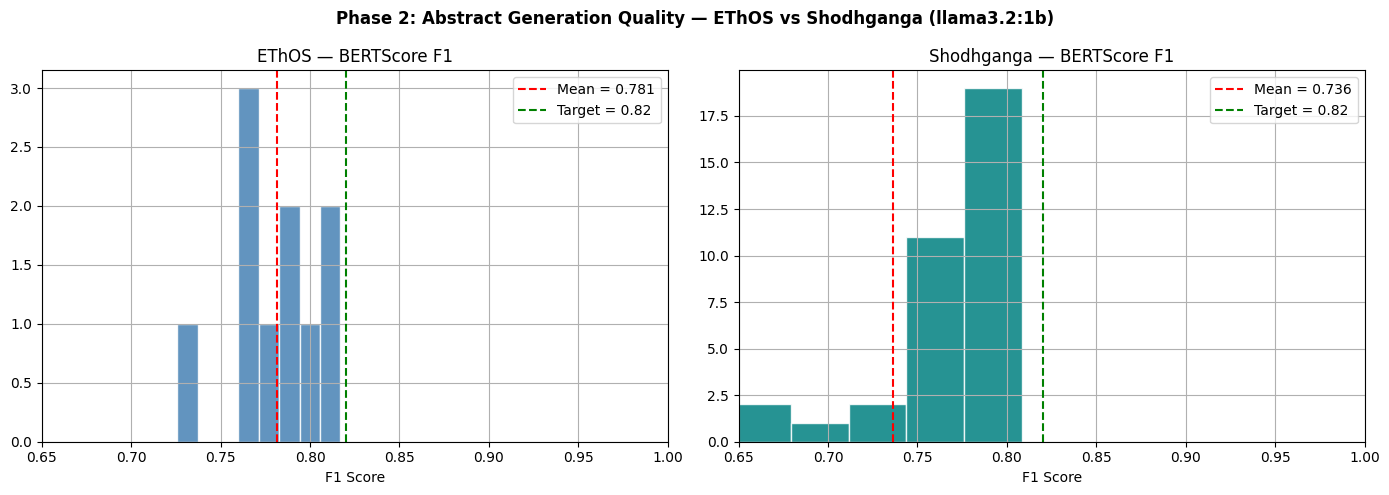

Saved to results/figures/bertscore_both_corpora.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# EThOS F1 distribution
valid["bertscore_f1"].hist(
    bins=8, ax=axes[0],
    color="steelblue", edgecolor="white", alpha=0.85
)
axes[0].axvline(valid["bertscore_f1"].mean(), color="red",
                linestyle="--", label=f"Mean = {valid['bertscore_f1'].mean():.3f}")
axes[0].axvline(0.82, color="green",
                linestyle="--", label="Target = 0.82")
axes[0].set_title("EThOS — BERTScore F1")
axes[0].set_xlabel("F1 Score")
axes[0].set_xlim(0.65, 1.0)
axes[0].legend()

# Shodhganga F1 distribution
valid_shod["bertscore_f1"].hist(
    bins=8, ax=axes[1],
    color="teal", edgecolor="white", alpha=0.85
)
axes[1].axvline(valid_shod["bertscore_f1"].mean(), color="red",
                linestyle="--", label=f"Mean = {F1_s.mean():.3f}")
axes[1].axvline(0.82, color="green",
                linestyle="--", label="Target = 0.82")
axes[1].set_title("Shodhganga — BERTScore F1")
axes[1].set_xlabel("F1 Score")
axes[1].set_xlim(0.65, 1.0)
axes[1].legend()

plt.suptitle("Phase 2: Abstract Generation Quality — EThOS vs Shodhganga (llama3.2:1b)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("../results/figures/bertscore_both_corpora.png", dpi=150)
plt.show()
print("Saved to results/figures/bertscore_both_corpora.png")

In [20]:
summary = pd.DataFrame({
    "Corpus":             ["EThOS (UK)",          "Shodhganga (India)"],
    "Records evaluated":  [len(valid),            len(valid_shod)],
    "Abstract source":    ["British Library",     "OpenAlex (via DOI)"],
    "BERTScore F1":       [round(F1.mean().item(), 4),
                           round(F1_s.mean().item(), 4)],
    "BERTScore P":        [round(P.mean().item(), 4),
                           round(P_s.mean().item(), 4)],
    "BERTScore R":        [round(R.mean().item(), 4),
                           round(R_s.mean().item(), 4)],
    "Target F1":          [0.82, 0.82],
    "Gap":                [round(0.82 - F1.mean().item(), 4),
                           round(0.82 - F1_s.mean().item(), 4)],
    "Model used":         ["llama3.2:1b", "llama3.2:1b"],
})

print("\n" + "=" * 60)
print("PHASE 2 COMPLETE — FINAL SUMMARY")
print("=" * 60)
print(summary.to_string(index=False))

summary.to_csv("../results/scores/phase2_final_summary.csv", index=False)
print("\nSaved to results/scores/phase2_final_summary.csv")


PHASE 2 COMPLETE — FINAL SUMMARY
            Corpus  Records evaluated    Abstract source  BERTScore F1  BERTScore P  BERTScore R  Target F1    Gap  Model used
        EThOS (UK)                 10    British Library        0.7813       0.8136       0.7518       0.82 0.0387 llama3.2:1b
Shodhganga (India)                 44 OpenAlex (via DOI)        0.7362       0.7643       0.7112       0.82 0.0838 llama3.2:1b

Saved to results/scores/phase2_final_summary.csv
